# Jet Fuel Hedging Strategy
**DCC-GARCH dynamic hedge ratios · Rolling futures with margin · FX forwards · Stress testing**


## 1 · Setup

In [1]:
# !pip install yfinance arch --quiet

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
from arch import arch_model

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d",   "axes.labelcolor": "#8b949e",
    "xtick.color": "#8b949e",      "ytick.color": "#8b949e",
    "text.color": "#e6edf3",       "grid.color": "#30363d",
    "grid.linewidth": 0.5,         "legend.facecolor": "#161b22",
    "legend.labelcolor": "#e6edf3",
})

VOLUME   = 10_000   # barrels
FX_RATIO = 0.80
LOOKBACK = 60

## 2 · Market Data
Jet fuel (Jet A) is not exchange-traded. We proxy it via the **3-2-1 crack spread**:
`Jet ≈ 0.5 × HO + 0.5 × RBOB` plus a mean-reverting AR(1) basis term.
Falls back to calibrated synthetic GBM data if Yahoo Finance is unreachable.


In [2]:
def load_data(start="2024-03-20", end="2025-03-20"):
    try:
        import yfinance as yf
        raw = {n: yf.download(t, start=start, end=end, progress=False)["Close"].squeeze()
               for t, n in {"HO=F":"HO","XB=F":"RBOB","CL=F":"CL","EURUSD=X":"FX"}.items()}
        df = pd.DataFrame(raw).dropna()
        if len(df) < 30: raise ValueError("not enough data")
        df["Jet_Fuel_Price"] = 0.5*df.HO + 0.5*df.RBOB
        df = df.rename(columns={"HO":"Fuel_Price","FX":"FX_Rate"})
        print("✓ Live data loaded")
    except Exception as e:
        print(f"Using synthetic data ({e})")
        dates = pd.bdate_range(start, end); n = len(dates); np.random.seed(0)
        vols  = np.array([.30,.32,.25,.06])
        corr  = np.array([[1,.82,.75,.08],[.82,1,.70,.06],[.75,.70,1,.05],[.08,.06,.05,1]])
        shocks = (np.linalg.cholesky(corr) @ np.random.randn(4,n)).T
        S = np.array([2.50,2.40,80.0,1.08])
        prices = np.zeros((n,4)); prices[0] = S
        for t in range(1,n):
            prices[t] = prices[t-1]*np.exp((-.5*vols**2)/252 + vols/np.sqrt(252)*shocks[t])
        df = pd.DataFrame(prices, columns=["Fuel_Price","RBOB","CL","FX_Rate"], index=dates)
        df["Jet_Fuel_Price"] = 0.5*df.Fuel_Price + 0.5*df.RBOB

    # AR(1) basis risk on top
    np.random.seed(42); n = len(df); basis = np.zeros(n)
    for t in range(1,n): basis[t] = 0.92*basis[t-1] + np.random.normal(0,.015)
    df["Basis"] = basis
    df["Jet_Fuel_Price"] += df.Basis
    return df[["Jet_Fuel_Price","Fuel_Price","FX_Rate","CL","RBOB","Basis"]].dropna()


def load_stress_scenario(name, df):
    df = df.copy(); t = np.linspace(0,1,len(df))
    profiles = {
        "mild":        1 + 0.1*np.sin(2*np.pi*t),
        "2008_spike":  1 + 1.5*np.sin(np.pi*t)*(t<.5) - .7*(t>=.5)*(t-.5)/.5,
        "2020_covid":  1 - 0.8*np.exp(-10*(t-.3)**2),
        "2022_energy": 1 + 1.2*t*np.exp(-2*t),
    }
    mul = np.maximum(profiles[name], 0.05)
    df["Fuel_Price"]     *= mul
    df["Jet_Fuel_Price"] *= mul
    df["CL"]             *= mul
    df["FX_Rate"]        *= 1 + 0.15*np.sin(1.5*np.pi*t + .5)
    return df


df = load_data()
print(f"{len(df)} days | Jet fuel ${df.Jet_Fuel_Price.min():.2f}–${df.Jet_Fuel_Price.max():.2f}/gal | FX {df.FX_Rate.min():.4f}–{df.FX_Rate.max():.4f}")
df.head()

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: XB=F"}}}

1 Failed download:
['XB=F']: YFTzMissingError('possibly delisted; no timezone found')


Using synthetic data (not enough data)
262 days | Jet fuel $2.12–$3.04/gal | FX 1.0334–1.1425


,Jet_Fuel_Price,Fuel_Price,FX_Rate,CL,RBOB,Basis
2024-03-20,2.450000,2.500000,1.080000,80.000000,2.400000,0.000000
2024-03-21,2.473700,2.518528,1.081894,79.637489,2.413972,0.007451
2024-03-22,2.486652,2.565087,1.076704,80.955636,2.398655,0.004781
2024-03-25,2.598944,2.675570,1.077174,84.354066,2.494091,0.014114
2024-03-26,2.715103,2.771192,1.074809,84.278745,2.587354,0.035830


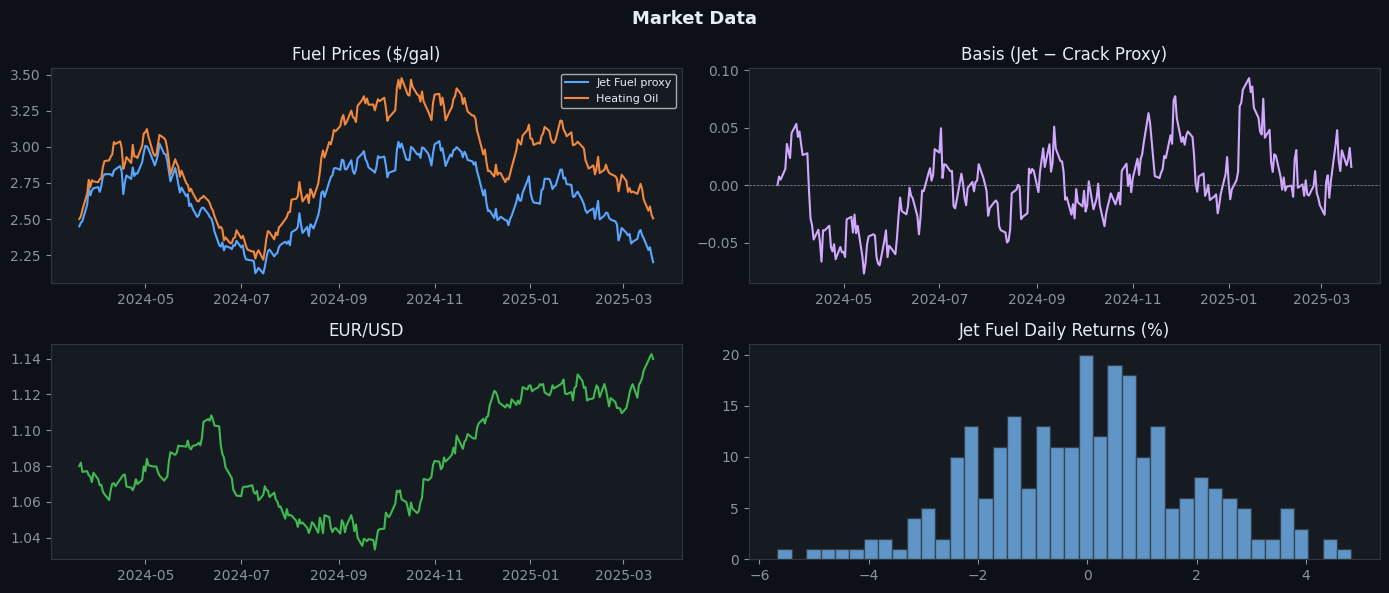

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14,6))
fig.suptitle("Market Data", fontsize=13, fontweight="bold")
axes[0,0].plot(df.Jet_Fuel_Price, color="#58a6ff", label="Jet Fuel proxy")
axes[0,0].plot(df.Fuel_Price,     color="#f0883e", label="Heating Oil"); axes[0,0].legend(fontsize=8)
axes[0,0].set_title("Fuel Prices ($/gal)")
axes[0,1].plot(df.Basis, color="#d2a8ff"); axes[0,1].axhline(0,color="#8b949e",lw=.5,ls="--")
axes[0,1].set_title("Basis (Jet − Crack Proxy)")
axes[1,0].plot(df.FX_Rate, color="#3fb950"); axes[1,0].set_title("EUR/USD")
ret = 100*np.log(df.Jet_Fuel_Price).diff().dropna()
axes[1,1].hist(ret, bins=40, color="#79c0ff", alpha=.75, edgecolor="#30363d")
axes[1,1].set_title("Jet Fuel Daily Returns (%)")
plt.tight_layout(); plt.show()

## 3 · Dynamic Hedge Ratio — DCC-GARCH(1,1)
**Step 1**: fit univariate GARCH(1,1) on each series → conditional vols σ_t and standardised residuals ε_t  
**Step 2**: DCC recursion `Q_t = (1−a−b)Q̄ + a·εε' + b·Q_{t-1}` → time-varying ρ_t  
**Hedge ratio**: `h_t = ρ_t · (σ_jet / σ_HO)`


In [4]:
def compute_hedge_ratio(df, lookback=60, a=0.05, b=0.90):
    jet = 100*np.log(df.Jet_Fuel_Price).diff().dropna()
    ho  = 100*np.log(df.Fuel_Price).diff().dropna()
    idx = jet.index.intersection(ho.index)
    jet, ho = jet[idx], ho[idx]

    # Step 1 – univariate GARCH
    res_j = arch_model(jet, vol="Garch", p=1, q=1).fit(disp="off", show_warning=False)
    res_h = arch_model(ho,  vol="Garch", p=1, q=1).fit(disp="off", show_warning=False)
    sj, sh = res_j.conditional_volatility, res_h.conditional_volatility
    ej, eh = (jet/sj).values, (ho/sh).values

    # Step 2 – DCC correlation
    Qbar = np.array([[1, np.corrcoef(ej,eh)[0,1]],[np.corrcoef(ej,eh)[0,1],1]])
    Q, rho = Qbar.copy(), np.zeros(len(idx))
    rho[0] = Qbar[0,1]
    for t in range(1, len(idx)):
        e = np.array([ej[t-1], eh[t-1]])
        Q = (1-a-b)*Qbar + a*np.outer(e,e) + b*Q
        rho[t] = Q[0,1] / np.sqrt(Q[0,0]*Q[1,1])

    h = np.clip(rho * sj.values / np.where(sh.values>0, sh.values, np.nan), 0, 2)
    result = pd.DataFrame({"hedge_ratio":h,"rho":rho,"sigma_jet":sj.values,"sigma_ho":sh.values}, index=idx)
    result.iloc[:lookback] = np.nan
    return result.bfill().reindex(df.index).bfill().ffill()


print("Fitting DCC-GARCH …")
hr_df = compute_hedge_ratio(df, lookback=LOOKBACK)
print(f"Mean hedge ratio: {hr_df.hedge_ratio.mean():.3f}  |  Mean ρ: {hr_df.rho.mean():.3f}")

Fitting DCC-GARCH …
Mean hedge ratio: 0.922  |  Mean ρ: 0.908


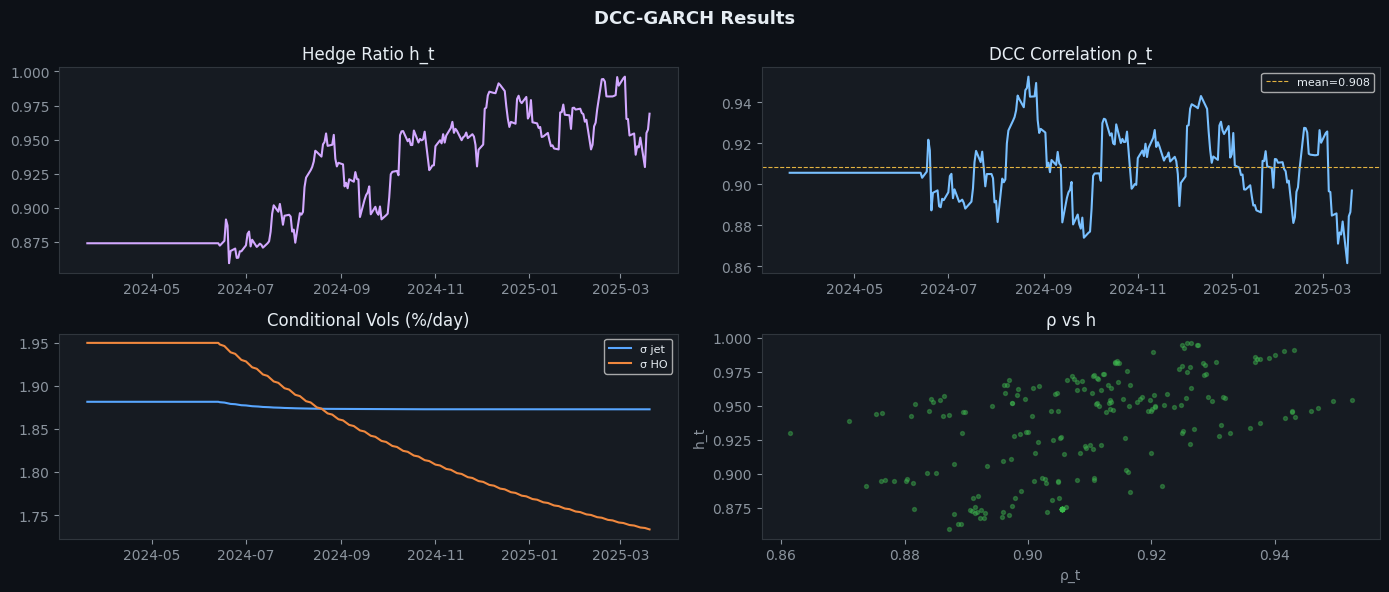

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14,6))
fig.suptitle("DCC-GARCH Results", fontsize=13, fontweight="bold")
axes[0,0].plot(hr_df.hedge_ratio, color="#d2a8ff"); axes[0,0].set_title("Hedge Ratio h_t")
axes[0,1].plot(hr_df.rho, color="#79c0ff")
axes[0,1].axhline(hr_df.rho.mean(), color="#e3b341", lw=.8, ls="--", label=f"mean={hr_df.rho.mean():.3f}")
axes[0,1].legend(fontsize=8); axes[0,1].set_title("DCC Correlation ρ_t")
axes[1,0].plot(hr_df.sigma_jet, color="#58a6ff", label="σ jet")
axes[1,0].plot(hr_df.sigma_ho,  color="#f0883e", label="σ HO")
axes[1,0].legend(fontsize=8); axes[1,0].set_title("Conditional Vols (%/day)")
axes[1,1].scatter(hr_df.rho, hr_df.hedge_ratio, s=8, alpha=.4, color="#3fb950")
axes[1,1].set_xlabel("ρ_t"); axes[1,1].set_ylabel("h_t"); axes[1,1].set_title("ρ vs h")
plt.tight_layout(); plt.show()

## 4 · Rolling Futures Hedge
Daily variation margin, NYMEX front-month roll costs, and margin-call tracking.


In [6]:
def futures_hedge(df, volume, hr_df,
                  contract_size=42000, fee=2.5, roll_cost=15,
                  init_margin=8000, maint_margin=6000):
    gallons = volume * 42
    # Approximate NYMEX roll dates: 3 biz days before 25th each month
    roll_dates = {(pd.Timestamp(y,m,25) - pd.tseries.offsets.BusinessDay(3)).normalize()
                  for y in df.index.year.unique() for m in range(1,13)}

    hedge_ratios = hr_df.hedge_ratio.reindex(df.index).bfill().ffill()
    daily_vm, contracts_list, margin_bal = [], [], []
    margin_calls = {}
    fees = rolls = 0.0
    prev_c = mb = 0.0

    for i, date in enumerate(df.index):
        c = max(int(hedge_ratios.iloc[i] * gallons / contract_size), 0)

        if date.normalize() in roll_dates and i > 0 and prev_c > 0:
            rc = prev_c * roll_cost; rolls += rc; mb -= rc

        fee_today = abs(c - prev_c) * fee; fees += fee_today; mb -= fee_today

        price_chg = 0 if i == 0 else df.Fuel_Price.iloc[i] - df.Fuel_Price.iloc[i-1]
        vm = -c * contract_size * price_chg
        daily_vm.append(vm); mb += vm

        if c > prev_c: mb -= (c - prev_c) * init_margin

        if mb < c * maint_margin and c > 0:
            call = c * maint_margin - mb + c * (init_margin - maint_margin)
            margin_calls[date] = call; mb += call

        contracts_list.append(c); margin_bal.append(mb); prev_c = c

    vm_s = pd.Series(daily_vm, index=df.index)
    return {
        "pnl": vm_s.cumsum(), "daily_vm": vm_s,
        "margin_account": pd.Series(margin_bal, index=df.index),
        "margin_calls": margin_calls, "contracts": contracts_list,
        "fees": fees, "roll_costs": rolls,
        "metadata": {"total_fees":fees,"total_roll_costs":rolls,
                     "total_margin_calls":sum(margin_calls.values()),
                     "num_margin_calls":len(margin_calls)},
    }


futures = futures_hedge(df, VOLUME, hr_df)
m = futures["metadata"]
print(f"Fees: ${m['total_fees']:,.0f}  |  Roll costs: ${m['total_roll_costs']:,.0f}  |  Margin calls: {m['num_margin_calls']} (${m['total_margin_calls']:,.0f})")

Fees: $52  |  Roll costs: $1,575  |  Margin calls: 16 ($547,290)


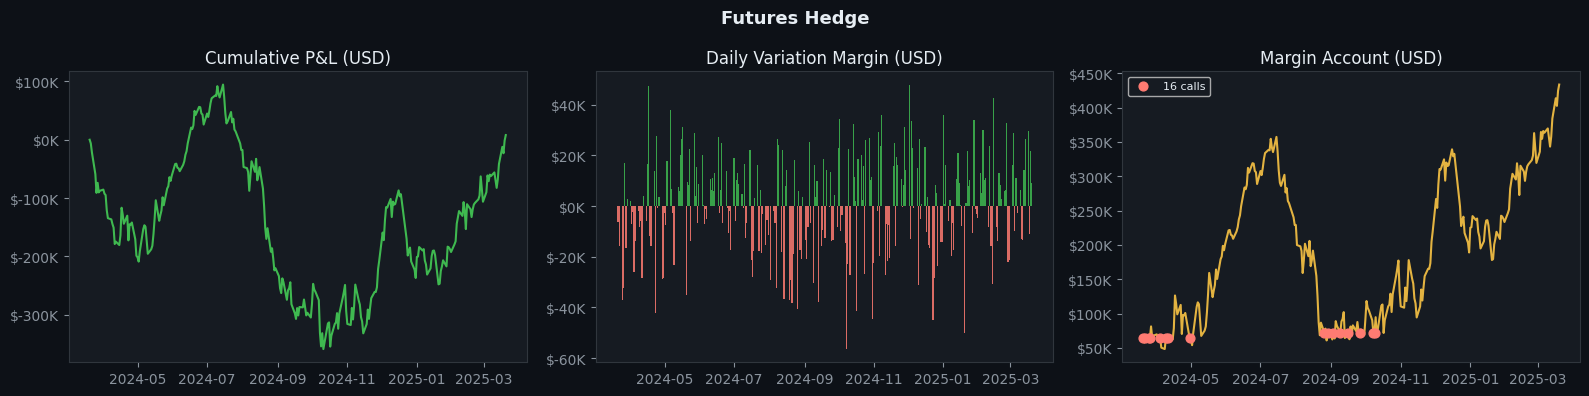

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
fig.suptitle("Futures Hedge", fontsize=13, fontweight="bold")
axes[0].plot(futures["pnl"], color="#3fb950")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"${x/1e3:.0f}K"))
axes[0].set_title("Cumulative P&L (USD)")
vm = futures["daily_vm"]
axes[1].bar(vm.index, vm.values, color=["#3fb950" if v>=0 else "#ff7b72" for v in vm], width=1, alpha=.85)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"${x/1e3:.0f}K"))
axes[1].set_title("Daily Variation Margin (USD)")
axes[2].plot(futures["margin_account"], color="#e3b341")
if futures["margin_calls"]:
    mcd = [d for d in futures["margin_calls"] if d in futures["margin_account"].index]
    axes[2].scatter(mcd, [futures["margin_account"].loc[d] for d in mcd],
                    color="#ff7b72", s=40, zorder=5, label=f"{len(mcd)} calls")
    axes[2].legend(fontsize=8)
axes[2].yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"${x/1e3:.0f}K"))
axes[2].set_title("Margin Account (USD)")
plt.tight_layout(); plt.show()

## 5 · FX Forward Hedge
Quarterly rolling forwards priced via covered interest-rate parity: `F = S × (1 + r_USD·T) / (1 + r_EUR·T)`


In [8]:
def fx_hedge(df, volume, ratio=0.8, r_usd=0.053, r_eur=0.034, tenor=90):
    usd_exp   = df.Jet_Fuel_Price * volume * 42
    daily_pnl = pd.Series(0.0, index=df.index)
    forwards  = []
    n = len(df)
    roll_idx = list(range(0, n, tenor)) + [n-1]

    for k in range(len(roll_idx)-1):
        si, ei  = roll_idx[k], min(roll_idx[k+1], n-1)
        T       = max((df.index[ei] - df.index[si]).days, 1) / 360
        fwd     = df.FX_Rate.iloc[si] * (1 + r_usd*T) / (1 + r_eur*T)
        notional = ratio * usd_exp.iloc[si:ei+1].mean()
        daily_pnl.iloc[si:ei+1] += notional * (fwd - df.FX_Rate.iloc[si:ei+1]) / max((df.index[ei]-df.index[si]).days,1)
        forwards.append({"start":df.index[si],"end":df.index[ei],"forward_rate":fwd,"notional_usd":notional})

    return {"pnl_eur": daily_pnl.cumsum(), "daily_pnl": daily_pnl, "forwards": forwards,
            "metadata": {"num_forwards":len(forwards),"avg_notional_usd":np.mean([f["notional_usd"] for f in forwards]),
                         "total_pnl_eur":daily_pnl.sum()}}


fx_out = fx_hedge(df, VOLUME, ratio=FX_RATIO)
m = fx_out["metadata"]
print(f"Forwards: {m['num_forwards']}  |  Avg notional: ${m['avg_notional_usd']:,.0f}  |  Total P&L: €{m['total_pnl_eur']:,.0f}")

Forwards: 3  |  Avg notional: $891,419  |  Total P&L: €-24


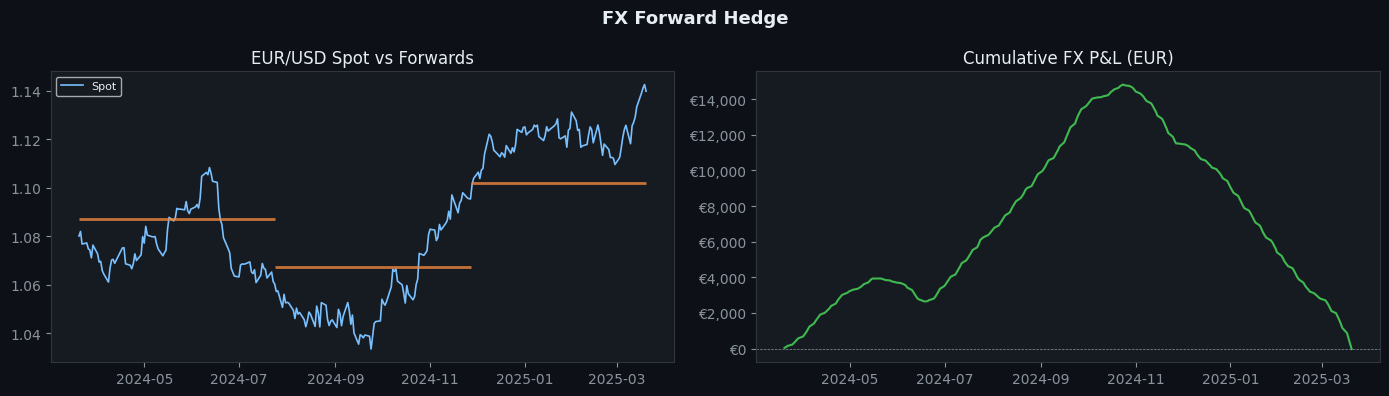

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))
fig.suptitle("FX Forward Hedge", fontsize=13, fontweight="bold")
axes[0].plot(df.FX_Rate, color="#79c0ff", lw=1.2, label="Spot")
for f in fx_out["forwards"]:
    axes[0].hlines(f["forward_rate"], f["start"], f["end"], colors="#f0883e", lw=2, alpha=.8)
axes[0].set_title("EUR/USD Spot vs Forwards"); axes[0].legend(fontsize=8)
axes[1].plot(fx_out["pnl_eur"], color="#3fb950")
axes[1].axhline(0, color="#8b949e", lw=.5, ls="--")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"€{x:,.0f}"))
axes[1].set_title("Cumulative FX P&L (EUR)")
plt.tight_layout(); plt.show()

## 6 · Hedged vs Unhedged Cost

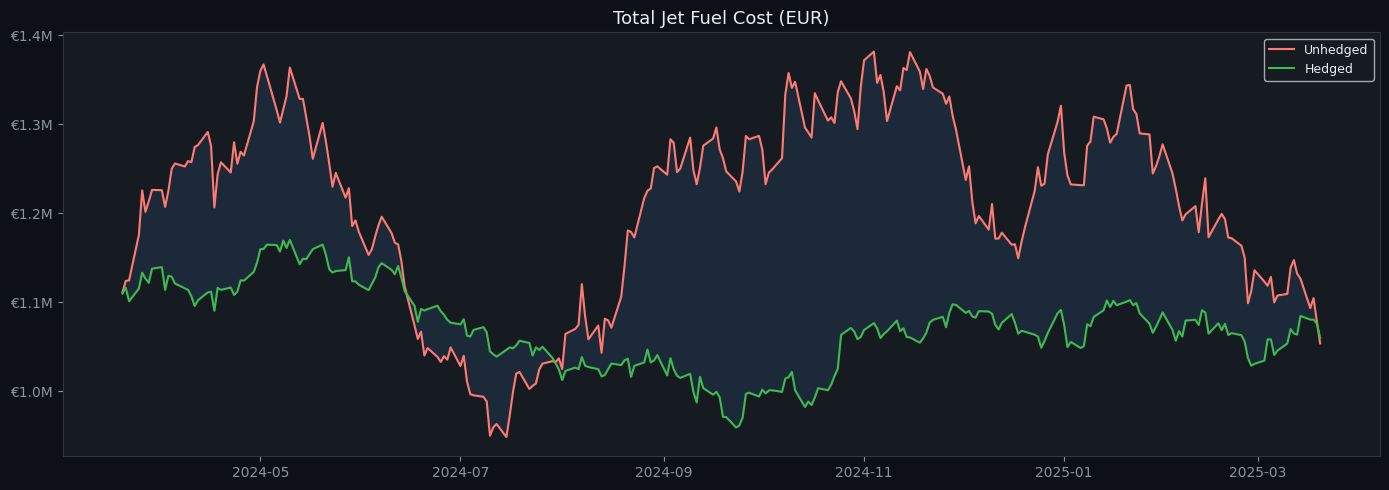

Mean daily saving: €138,526  |  Total saving: €36,293,691


In [10]:
physical = VOLUME * df.Jet_Fuel_Price * df.FX_Rate * 42
hedged   = physical + futures["pnl"] + fx_out["pnl_eur"] - futures["fees"] - futures["roll_costs"]

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(physical, color="#ff7b72", lw=1.5, label="Unhedged")
ax.plot(hedged,   color="#3fb950", lw=1.5, label="Hedged")
ax.fill_between(df.index, np.minimum(physical,hedged), np.maximum(physical,hedged), alpha=.1, color="#58a6ff")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"€{x/1e6:.1f}M"))
ax.legend(fontsize=9); ax.set_title("Total Jet Fuel Cost (EUR)", fontsize=13)
plt.tight_layout(); plt.show()
print(f"Mean daily saving: €{(physical-hedged).mean():,.0f}  |  Total saving: €{(physical-hedged).sum():,.0f}")

## 7 · Hedge Effectiveness
- **HER** = `1 − Var(hedged) / Var(unhedged)` — IFRS 9 requires 80%–125%  
- **CVaR** (Expected Shortfall) at 95% and 99%


In [11]:
def effectiveness(physical, hedged, window=30):
    u, h = physical.diff().dropna(), hedged.diff().dropna()
    her  = 1 - h.var()/u.var()

    rolling = pd.Series(index=u.index, dtype=float)
    for i in range(window, len(u)):
        ui, hi = u.iloc[i-window:i], h.iloc[i-window:i]
        rolling.iloc[i] = 1 - hi.var()/ui.var()

    def cvar(s, a): tail = s[s >= s.quantile(1-a)]; return tail.mean()

    return {
        "HER": her, "rolling_her": rolling,
        "ifrs9": 0.8 <= her <= 1.25,
        "cvar95_u": cvar(u,.95), "cvar95_h": cvar(h,.95),
        "cvar99_u": cvar(u,.99), "cvar99_h": cvar(h,.99),
        "var_u": u.var(), "var_h": h.var(),
        "mean_saving": -(hedged-physical).mean(),
        "pct_saving":  -(hedged-physical).mean()/physical.mean()*100,
        "max_dd": ((hedged-hedged.cummax())/hedged.cummax()*100).min(),
        "u_ret": u, "h_ret": h,
    }


rep = effectiveness(physical, hedged)
print(f"HER: {rep['HER']*100:.1f}%  |  IFRS 9: {'✓' if rep['ifrs9'] else '✗'}")
print(f"CVaR-95: €{rep['cvar95_u']:,.0f} → €{rep['cvar95_h']:,.0f}  ({(1-rep['cvar95_h']/rep['cvar95_u'])*100:.1f}% reduction)")
print(f"CVaR-99: €{rep['cvar99_u']:,.0f} → €{rep['cvar99_h']:,.0f}")
print(f"Mean daily saving: €{rep['mean_saving']:,.0f}  ({rep['pct_saving']:.1f}%)  |  Max drawdown: {rep['max_dd']:.1f}%")

HER: 79.3%  |  IFRS 9: ✗
CVaR-95: €2,491 → €999  (59.9% reduction)
CVaR-99: €522 → €118
Mean daily saving: €138,526  (11.5%)  |  Max drawdown: -18.0%


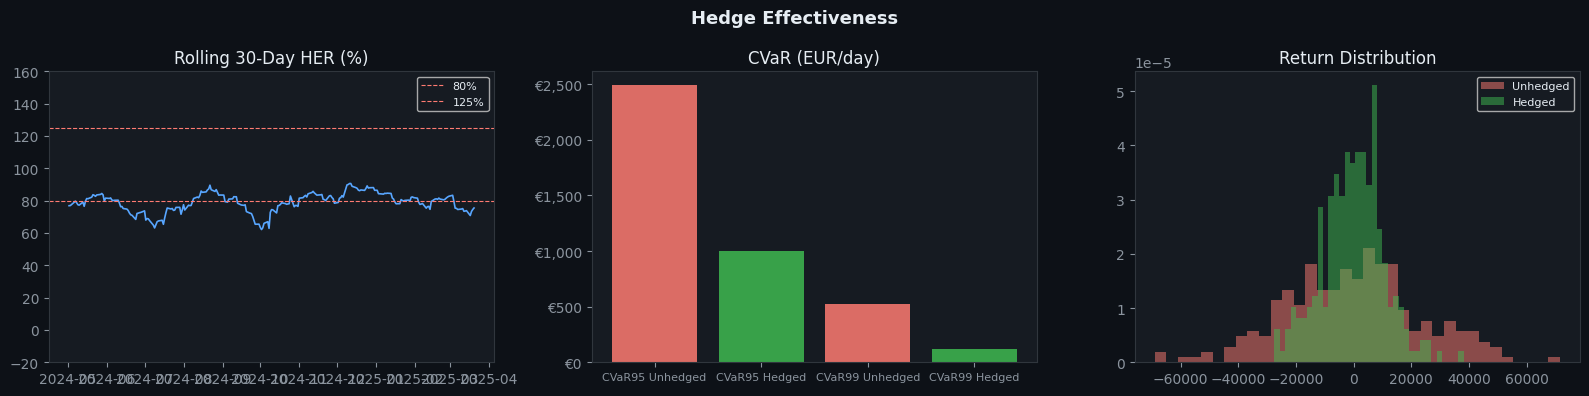

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
fig.suptitle("Hedge Effectiveness", fontsize=13, fontweight="bold")
rolling = rep["rolling_her"].dropna()*100
axes[0].plot(rolling, color="#58a6ff", lw=1.2)
axes[0].axhline(80,  color="#ff7b72", ls="--", lw=.8, label="80%")
axes[0].axhline(125, color="#ff7b72", ls="--", lw=.8, label="125%")
axes[0].set_title("Rolling 30-Day HER (%)"); axes[0].legend(fontsize=8); axes[0].set_ylim(-20,160)
labels = ["CVaR95 Unhedged", "CVaR95 Hedged", "CVaR99 Unhedged", "CVaR99 Hedged"]
vals   = [rep["cvar95_u"],rep["cvar95_h"],rep["cvar99_u"],rep["cvar99_h"]]
axes[1].bar(labels, vals, color=["#ff7b72","#3fb950","#ff7b72","#3fb950"], alpha=.85)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"€{x:,.0f}"))
axes[1].set_title("CVaR (EUR/day)"); axes[1].tick_params(axis="x", labelsize=8)
axes[2].hist(rep["u_ret"], bins=35, alpha=.5, color="#ff7b72", label="Unhedged", density=True)
axes[2].hist(rep["h_ret"], bins=35, alpha=.5, color="#3fb950", label="Hedged",   density=True)
axes[2].set_title("Return Distribution"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8 · Stress Scenarios

In [13]:
def run(df, fx_ratio=FX_RATIO, lookback=LOOKBACK):
    hr  = compute_hedge_ratio(df, lookback=lookback)
    fut = futures_hedge(df, VOLUME, hr)
    fx  = fx_hedge(df, VOLUME, ratio=fx_ratio)
    phy = VOLUME * df.Jet_Fuel_Price * df.FX_Rate * 42
    hdg = phy + fut["pnl"] + fx["pnl_eur"] - fut["fees"] - fut["roll_costs"]
    return {"futures":fut,"fx":fx,"physical":phy,"hedged":hdg}


rows = []
for name in ["mild","2008_spike","2020_covid","2022_energy"]:
    out = run(load_stress_scenario(name, df))
    r   = effectiveness(out["physical"], out["hedged"])
    mc  = sum(out["futures"]["margin_calls"].values())
    cvar_red = (1 - r["cvar95_h"]/r["cvar95_u"])*100
    rows.append({"Scenario":name, "HER (%)":round(r["HER"]*100,1),
                 "IFRS9": "✓" if r["ifrs9"] else "✗",
                 "CVaR-95 Unhedged":round(r["cvar95_u"],0),
                 "CVaR-95 Hedged":round(r["cvar95_h"],0),
                 "CVaR Reduction (%)":round(cvar_red,1),
                 "Mean Daily Saving":round(r["mean_saving"],0),
                 "Max Drawdown (%)":round(r["max_dd"],1),
                 "Margin Calls ($)":round(mc,0),
                 "# Margin Calls":out["futures"]["metadata"]["num_margin_calls"]})

stress_df = pd.DataFrame(rows).set_index("Scenario")
stress_df

,HER (%),IFRS9,CVaR-95 Unhedged,CVaR-95 Hedged,CVaR Reduction (%),Mean Daily Saving,Max Drawdown (%),Margin Calls ($),# Margin Calls
Scenario,,,,,,,,,
mild,77.1,✗,1691.0,671.0,60.3,131054.0,-33.5,481607.0,15
2008_spike,97.6,✓,8199.0,2517.0,69.3,437396.0,-44.0,2414681.0,49
2020_covid,81.8,✓,2348.0,294.0,87.5,5185.0,-25.0,729586.0,21
2022_energy,78.8,✗,2706.0,850.0,68.6,329066.0,-33.0,820107.0,21


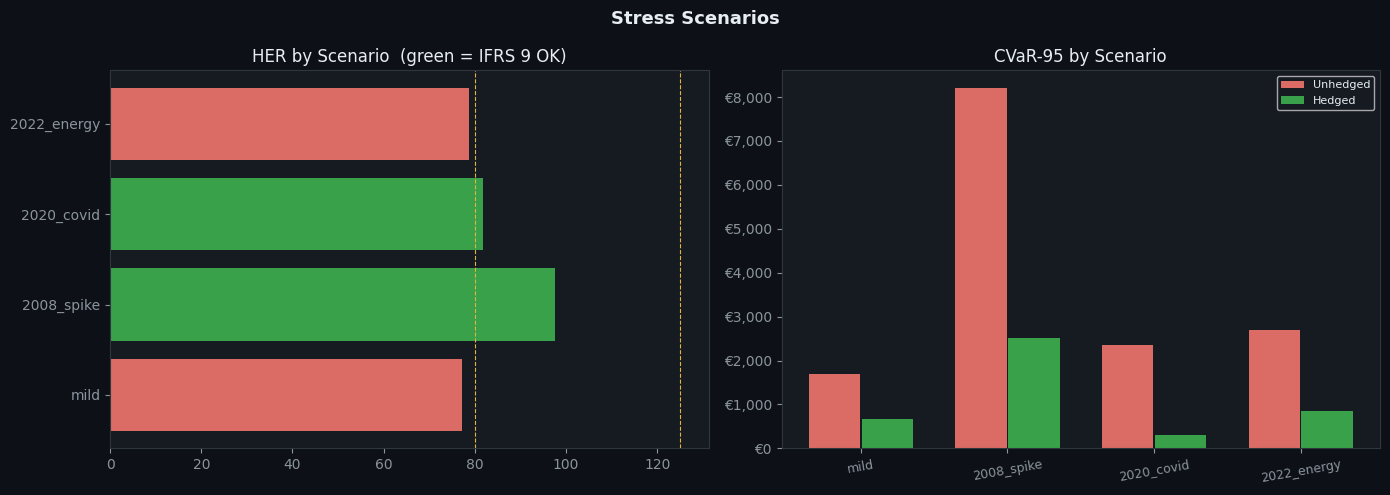

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle("Stress Scenarios", fontsize=13, fontweight="bold")
hv = stress_df["HER (%)"].values; hl = stress_df.index.tolist()
axes[0].barh(hl, hv, color=["#3fb950" if 80<=v<=125 else "#ff7b72" for v in hv], alpha=.85)
axes[0].axvline(80, color="#e3b341",ls="--",lw=.8); axes[0].axvline(125, color="#e3b341",ls="--",lw=.8)
axes[0].set_title("HER by Scenario  (green = IFRS 9 OK)")
x = np.arange(len(stress_df))
axes[1].bar(x-.18, stress_df["CVaR-95 Unhedged"], .35, color="#ff7b72", alpha=.85, label="Unhedged")
axes[1].bar(x+.18, stress_df["CVaR-95 Hedged"],   .35, color="#3fb950", alpha=.85, label="Hedged")
axes[1].set_xticks(x); axes[1].set_xticklabels(stress_df.index, rotation=10, fontsize=9)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"€{x:,.0f}"))
axes[1].set_title("CVaR-95 by Scenario"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 9 · Parameter Optimisation
Grid search over FX hedge ratio × GARCH lookback to minimise CVaR-95.

In [15]:
rows = []
for fx in [0.6, 0.7, 0.8, 0.9]:
    for lb in [40, 60, 80]:
        out = run(df, fx_ratio=fx, lookback=lb)
        r   = effectiveness(out["physical"], out["hedged"])
        rows.append({"FX_Ratio":fx,"Lookback":lb,"HER (%)":round(r["HER"]*100,1),
                     "IFRS9":"✓" if r["ifrs9"] else "✗",
                     "CVaR-95":round(r["cvar95_h"],0),
                     "Mean_Cost":round(out["hedged"].mean(),0)})

opt_df = pd.DataFrame(rows)
best   = opt_df.sort_values("CVaR-95").iloc[0]
print(f"Best → FX={best.FX_Ratio}, Lookback={int(best.Lookback)}, CVaR-95=€{best['CVaR-95']:,.0f}, HER={best['HER (%)']:.1f}%")
opt_df.sort_values("CVaR-95")

Best → FX=0.8, Lookback=40, CVaR-95=€999, HER=79.3%


,FX_Ratio,Lookback,HER (%),IFRS9,CVaR-95,Mean_Cost
6,0.8,40,79.3,✗,999.0,1070717.0
7,0.8,60,79.3,✗,999.0,1070717.0
9,0.9,40,79.3,✗,999.0,1071593.0
8,0.8,80,79.3,✗,999.0,1070717.0
11,0.9,80,79.3,✗,999.0,1071593.0
10,0.9,60,79.3,✗,999.0,1071593.0
0,0.6,40,79.3,✗,1000.0,1068966.0
1,0.6,60,79.3,✗,1000.0,1068966.0
4,0.7,60,79.3,✗,1000.0,1069842.0
5,0.7,80,79.3,✗,1000.0,1069842.0


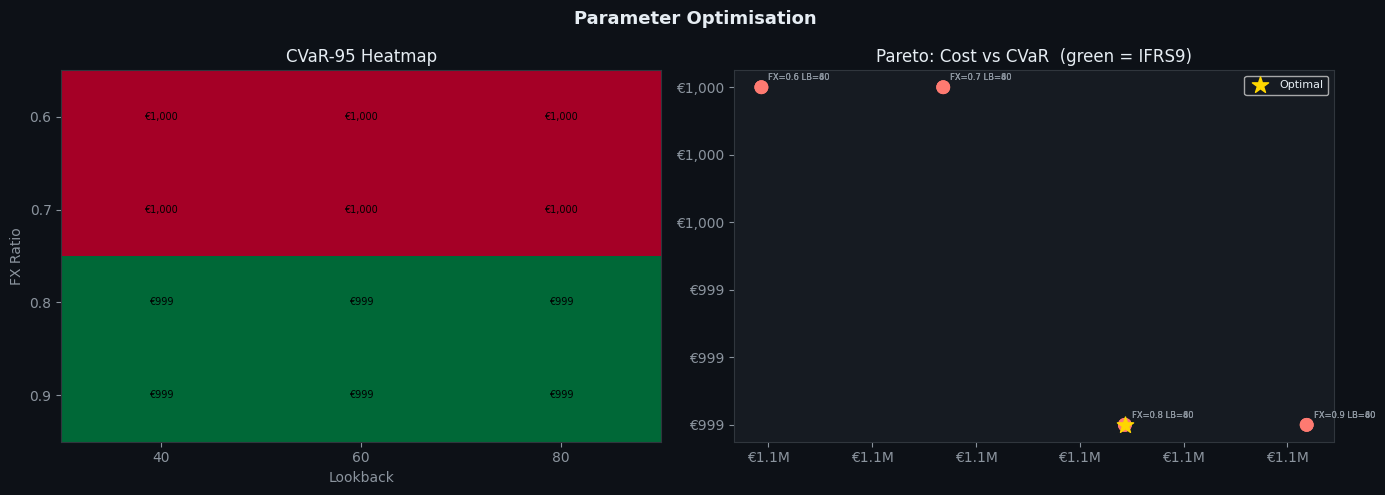

In [16]:
pivot = opt_df.pivot(index="FX_Ratio", columns="Lookback", values="CVaR-95")
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle("Parameter Optimisation", fontsize=13, fontweight="bold")
im = axes[0].imshow(pivot.values, aspect="auto", cmap="RdYlGn_r")
axes[0].set_xticks(range(len(pivot.columns))); axes[0].set_xticklabels(pivot.columns)
axes[0].set_yticks(range(len(pivot.index)));   axes[0].set_yticklabels(pivot.index)
axes[0].set_xlabel("Lookback"); axes[0].set_ylabel("FX Ratio")
axes[0].set_title("CVaR-95 Heatmap")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        axes[0].text(j,i,f"€{pivot.values[i,j]:,.0f}",ha="center",va="center",fontsize=7,color="black")
cols = ["#3fb950" if r=="✓" else "#ff7b72" for r in opt_df.IFRS9]
axes[1].scatter(opt_df.Mean_Cost, opt_df["CVaR-95"], c=cols, s=80, alpha=.85, zorder=3)
axes[1].scatter(best.Mean_Cost, best["CVaR-95"], c="gold", s=150, zorder=5, marker="*", label="Optimal")
for _, row in opt_df.iterrows():
    axes[1].annotate(f"FX={row.FX_Ratio} LB={int(row.Lookback)}",
                     (row.Mean_Cost, row["CVaR-95"]), xytext=(5,5),
                     textcoords="offset points", fontsize=6, color="#8b949e")
axes[1].set_title("Pareto: Cost vs CVaR  (green = IFRS9)"); axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x,_: f"€{x/1e6:.1f}M"))
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"€{x:,.0f}"))
plt.tight_layout(); plt.show()

## 10 · Full Dashboard

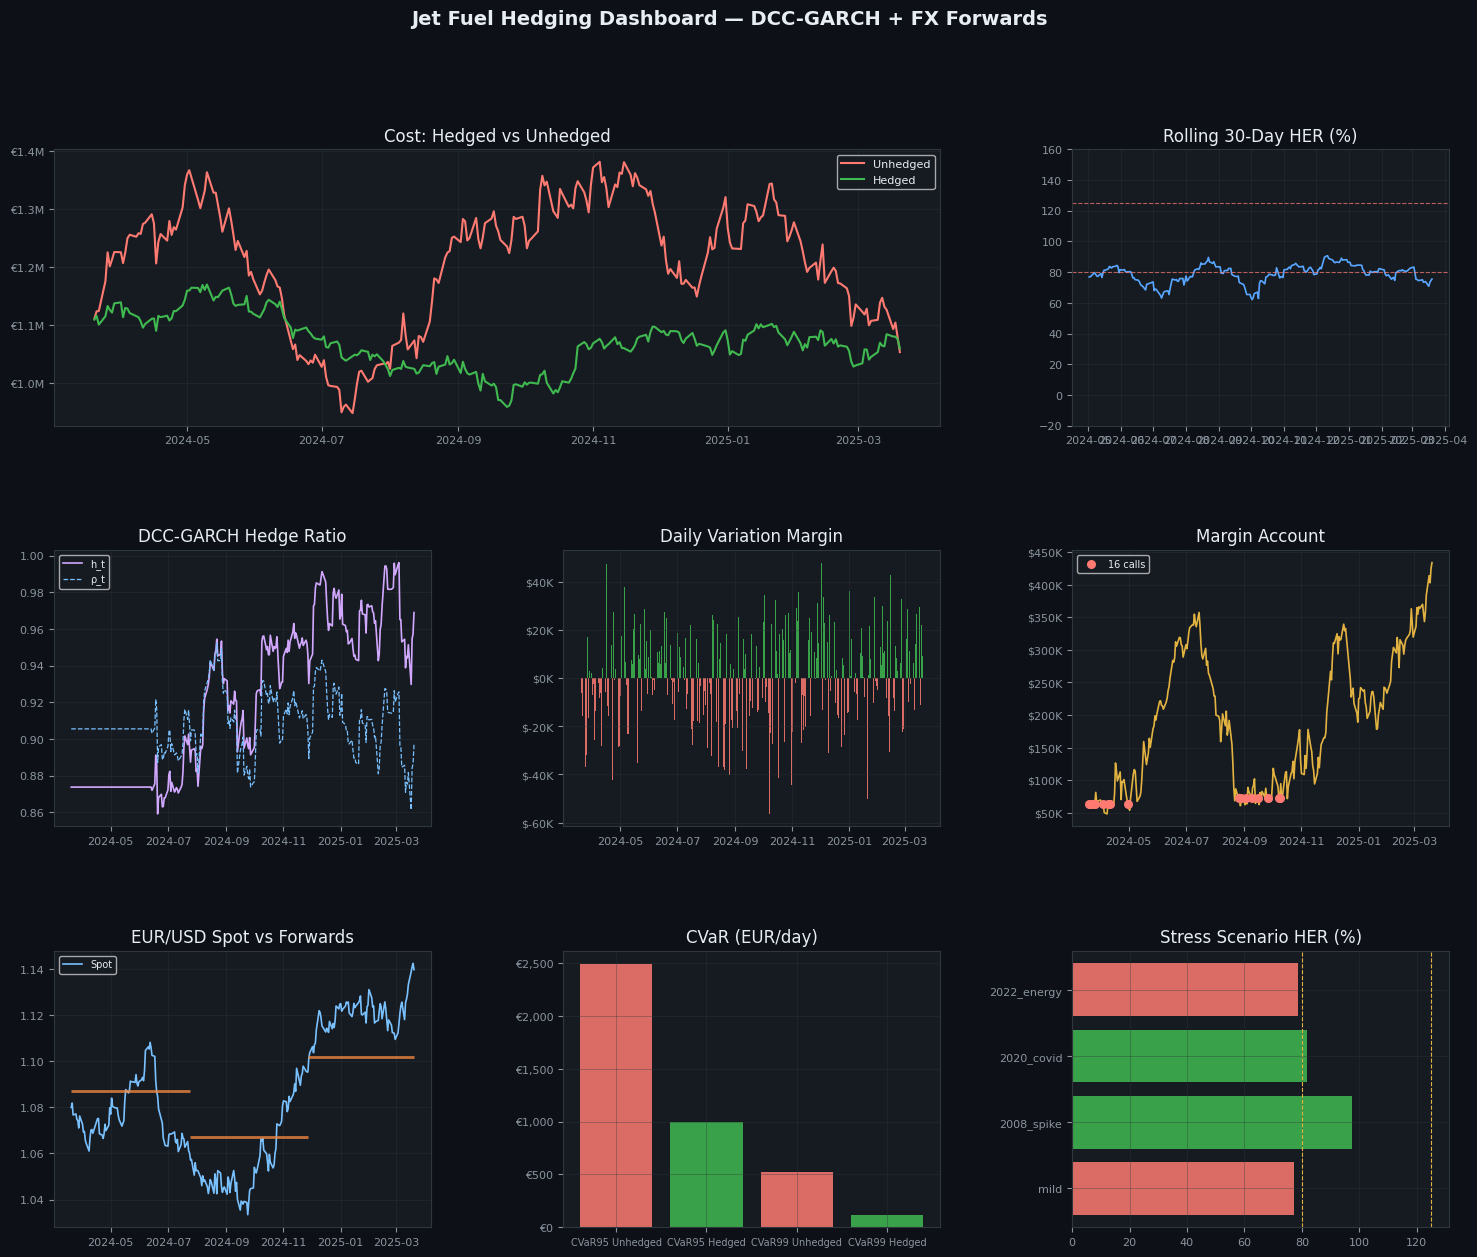

In [17]:
eur = FuncFormatter(lambda x,_: f"€{x/1e6:.1f}M")
usd = FuncFormatter(lambda x,_: f"${x/1e3:.0f}K")
eur2= FuncFormatter(lambda x,_: f"€{x:,.0f}")

fig = plt.figure(figsize=(18,14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=.45, wspace=.35)
fig.suptitle("Jet Fuel Hedging Dashboard — DCC-GARCH + FX Forwards",
             fontsize=14, fontweight="bold", y=.98)

def ax(pos):
    a = fig.add_subplot(pos)
    a.set_facecolor("#161b22"); a.grid(color="#30363d",lw=.5,alpha=.5)
    for sp in a.spines.values(): sp.set_color("#30363d")
    a.tick_params(colors="#8b949e",labelsize=8)
    a.title.set_color("#e6edf3"); a.xaxis.label.set_color("#8b949e"); a.yaxis.label.set_color("#8b949e")
    return a

a1 = ax(gs[0,:2])
a1.plot(physical, color="#ff7b72", lw=1.5, label="Unhedged")
a1.plot(hedged,   color="#3fb950", lw=1.5, label="Hedged")
a1.yaxis.set_major_formatter(eur); a1.legend(fontsize=8); a1.set_title("Cost: Hedged vs Unhedged")

a2 = ax(gs[0,2])
rolling = rep["rolling_her"].dropna()*100
a2.plot(rolling, color="#58a6ff", lw=1.2)
a2.axhline(80, color="#ff7b72",ls="--",lw=.8,alpha=.7); a2.axhline(125, color="#ff7b72",ls="--",lw=.8,alpha=.7)
a2.set_title("Rolling 30-Day HER (%)"); a2.set_ylim(-20,160)

a3 = ax(gs[1,0])
a3.plot(hr_df.hedge_ratio, color="#d2a8ff", lw=1.2, label="h_t")
a3.plot(hr_df.rho,         color="#79c0ff", lw=.9, ls="--", label="ρ_t")
a3.legend(fontsize=7); a3.set_title("DCC-GARCH Hedge Ratio")

a4 = ax(gs[1,1])
vm = futures["daily_vm"]
a4.bar(vm.index, vm.values, color=["#3fb950" if v>=0 else "#ff7b72" for v in vm], width=1, alpha=.85)
a4.yaxis.set_major_formatter(usd); a4.set_title("Daily Variation Margin")

a5 = ax(gs[1,2])
a5.plot(futures["margin_account"], color="#e3b341", lw=1.2)
mcd = [d for d in futures["margin_calls"] if d in futures["margin_account"].index]
if mcd:
    a5.scatter(mcd,[futures["margin_account"].loc[d] for d in mcd],
               color="#ff7b72",s=30,zorder=5,label=f"{len(mcd)} calls")
    a5.legend(fontsize=7)
a5.yaxis.set_major_formatter(usd); a5.set_title("Margin Account")

a6 = ax(gs[2,0])
a6.plot(df.FX_Rate, color="#79c0ff", lw=1.2, label="Spot")
for f in fx_out["forwards"]:
    a6.hlines(f["forward_rate"],f["start"],f["end"],colors="#f0883e",lw=2,alpha=.8)
a6.legend(fontsize=7); a6.set_title("EUR/USD Spot vs Forwards")

a7 = ax(gs[2,1])
labels = ["CVaR95 Unhedged", "CVaR95 Hedged", "CVaR99 Unhedged", "CVaR99 Hedged"]
vals   = [rep["cvar95_u"],rep["cvar95_h"],rep["cvar99_u"],rep["cvar99_h"]]
a7.bar(labels, vals, color=["#ff7b72","#3fb950","#ff7b72","#3fb950"], alpha=.85)
a7.yaxis.set_major_formatter(eur2); a7.set_title("CVaR (EUR/day)"); a7.tick_params(axis="x",labelsize=7)

a8 = ax(gs[2,2])
hv = stress_df["HER (%)"].values; hl = stress_df.index.tolist()
a8.barh(hl, hv, color=["#3fb950" if 80<=v<=125 else "#ff7b72" for v in hv], alpha=.85)
a8.axvline(80,color="#e3b341",ls="--",lw=.8); a8.axvline(125,color="#e3b341",ls="--",lw=.8)
a8.set_title("Stress Scenario HER (%)")

plt.show()

## 11 · Summary

| Module | Technique |
|---|---|
| Jet fuel proxy | 3-2-1 crack spread + AR(1) basis |
| Hedge ratio | DCC-GARCH(1,1) (Engle 2002) |
| Futures | Daily MTM, roll costs, margin calls |
| FX | Quarterly rolling forwards (IRP pricing) |
| Effectiveness | HER, CVaR, rolling IFRS 9 compliance |
| Stress testing | 4 historical shock profiles |
| Optimisation | Grid search → Pareto frontier |
